In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -dssssws/chocolate-sales-dataset-2023-2024

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024
License(s): apache-2.0
100% 23.3M/23.3M [00:02<00:00, 8.71MB/s]



In [3]:
 !unzip /content/chocolate-sales-dataset-2023-2024.zip

Archive:  /content/chocolate-sales-dataset-2023-2024.zip
  inflating: calendar.csv            
  inflating: customers.csv           
  inflating: products.csv            
  inflating: sales.csv               
  inflating: stores.csv              


# loading data

In [4]:
customer=pd.read_csv("/content/customers.csv")
customer

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31
...,...,...,...,...,...
49995,C049996,30,Female,1,2022-11-21
49996,C049997,24,Female,0,2022-08-30
49997,C049998,53,Male,0,2024-09-22
49998,C049999,31,Female,1,2025-08-23


In [5]:
product=pd.read_csv("/content/products.csv")
product

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50
...,...,...,...,...,...,...
195,P0196,White Chocolate 60%,Mars,Praline,60,80
196,P0197,Truffle Chocolate 90%,Hershey,Truffle,90,120
197,P0198,Dark Chocolate 90%,Ferrero,White,90,80
198,P0199,Dark Chocolate 70%,Hershey,White,70,80


In [6]:
sales=pd.read_csv("/content/sales.csv")
sales

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40
...,...,...,...,...,...,...,...,...,...,...,...
999995,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,12.53
999996,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,4.37
999997,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,8.16
999998,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,2.34


In [7]:
stores=pd.read_csv("/content/stores.csv")
stores

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online
...,...,...,...,...,...
95,S096,Chocolate Store 96,Berlin,UK,Mall
96,S097,Chocolate Store 97,Toronto,Canada,Mall
97,S098,Chocolate Store 98,New York,Australia,Online
98,S099,Chocolate Store 99,Toronto,Australia,Mall


In [8]:
tables = {
    'customer': customer,
    'product': product,
    'sales': sales,
    'stores': stores
}

for name, df in tables.items():
    print(name)
    print(df.columns)
    print("------")

customer
Index(['customer_id', 'age', 'gender', 'loyalty_member', 'join_date'], dtype='object')
------
product
Index(['product_id', 'product_name', 'brand', 'category', 'cocoa_percent',
       'weight_g'],
      dtype='object')
------
sales
Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit'],
      dtype='object')
------
stores
Index(['store_id', 'store_name', 'city', 'country', 'store_type'], dtype='object')
------


In [9]:
df = sales.merge(customer, on='customer_id', how='left')
df = df.merge(product, on='product_id', how='left')
df = df.merge(stores, on='store_id', how='left')

In [10]:
df.shape

(1000000, 24)

In [11]:
df

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,join_date,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,2021-11-17,Praline Chocolate 70%,Hershey,White,70.0,200.0,Chocolate Store 93,Sydney,UK,Airport
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,2023-07-03,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,Chocolate Store 65,New York,Australia,Retail
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,2023-10-09,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,Chocolate Store 78,London,UK,Airport
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,2023-05-30,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,Chocolate Store 88,Toronto,USA,Retail
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,2021-08-20,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,Chocolate Store 54,London,Canada,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,...,2025-04-21,Praline Chocolate 50%,Ferrero,White,50.0,100.0,Chocolate Store 53,New York,USA,Retail
999996,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,...,2022-07-23,Dark Chocolate 50%,Ferrero,Dark,50.0,200.0,Chocolate Store 58,Paris,USA,Airport
999997,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,...,2022-03-31,Milk Chocolate 80%,Godiva,Milk,80.0,50.0,Chocolate Store 41,London,Germany,Airport
999998,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,...,2021-12-25,Dark Chocolate 50%,Hershey,Praline,50.0,120.0,Chocolate Store 83,Toronto,France,Mall


In [12]:
df.isna().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [13]:
df = df.dropna(subset=['product_name'])

In [14]:
df.isna().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [15]:
df.shape

(990236, 24)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 990236 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        990236 non-null  object 
 1   order_date      990236 non-null  object 
 2   product_id      990236 non-null  object 
 3   store_id        990236 non-null  object 
 4   customer_id     990236 non-null  object 
 5   quantity        990236 non-null  int64  
 6   unit_price      990236 non-null  float64
 7   discount        990236 non-null  float64
 8   revenue         990236 non-null  float64
 9   cost            990236 non-null  float64
 10  profit          990236 non-null  float64
 11  age             990236 non-null  int64  
 12  gender          990236 non-null  object 
 13  loyalty_member  990236 non-null  int64  
 14  join_date       990236 non-null  object 
 15  product_name    990236 non-null  object 
 16  brand           990236 non-null  object 
 17  category       

In [17]:
df.describe()

,quantity,unit_price,discount,revenue,cost,profit,age,loyalty_member,cocoa_percent,weight_g
count,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000
mean,2.999760,9.002360,0.056242,25.487508,15.292310,10.195188,44.044334,0.501855,69.148132,107.431400
std,1.413644,3.462932,0.076806,16.369318,9.973389,6.779455,15.330031,0.499997,14.597137,50.719617
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,18.000000,0.000000,50.000000,50.000000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,31.000000,0.000000,50.000000,80.000000
50%,3.000000,9.000000,0.000000,21.920000,13.030000,8.610000,44.000000,1.000000,70.000000,100.000000
75%,4.000000,12.000000,0.150000,35.880000,21.420000,14.170000,57.000000,1.000000,80.000000,120.000000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,70.000000,1.000000,90.000000,200.000000


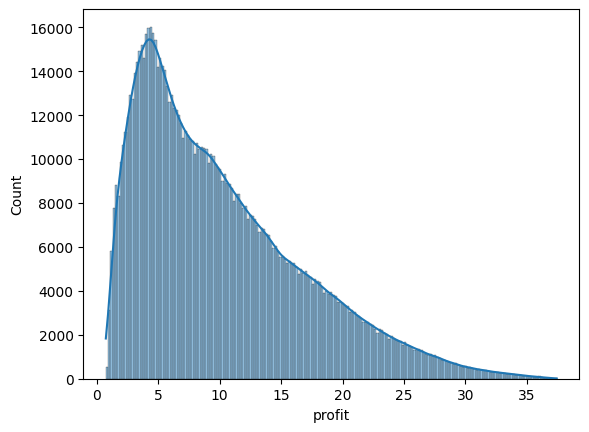

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['profit'], kde=True)
plt.show()

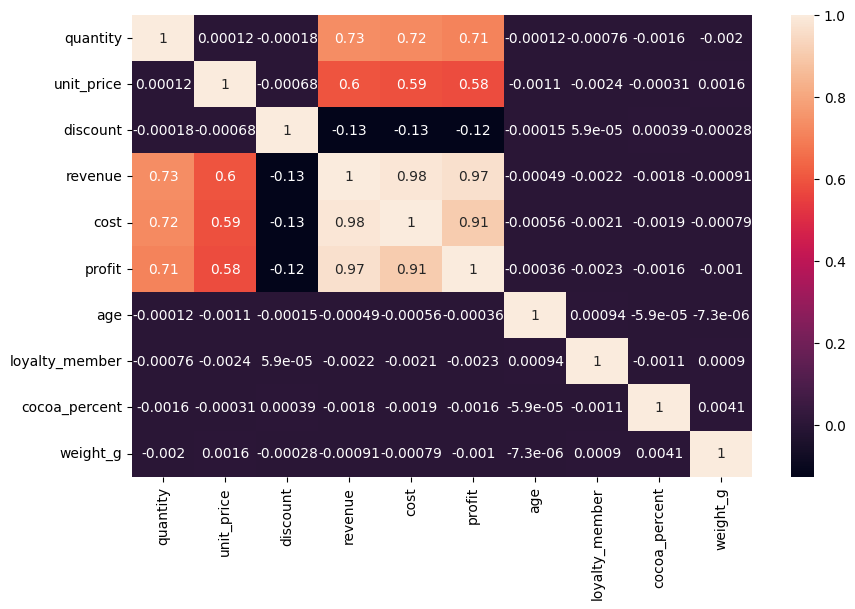

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


# Time series analysis

/tmp/ipykernel_2955/210329285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_date'] = pd.to_datetime(df['order_date'])


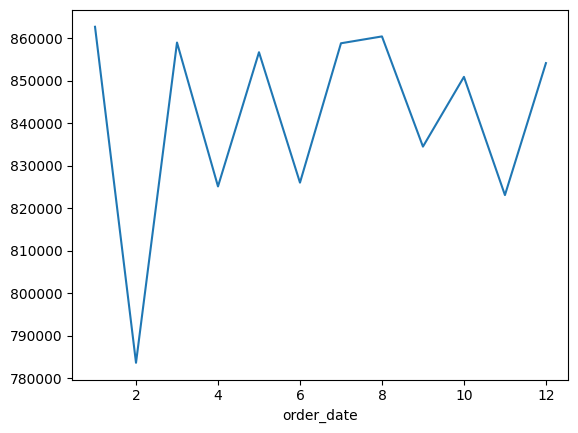

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])

df.groupby(df['order_date'].dt.month)['profit'].sum().plot()
plt.show()

# Distribution of loyalty Members

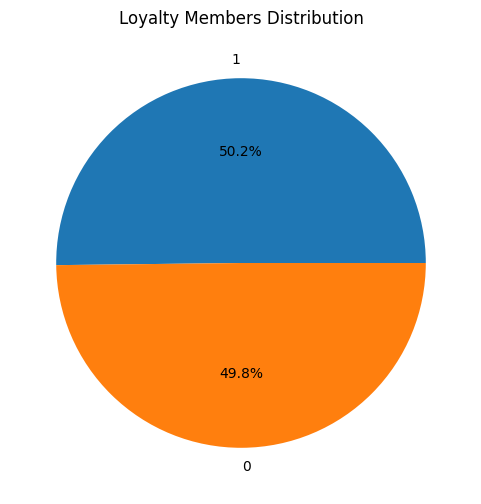

In [21]:
loyalty_counts = df['loyalty_member'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(loyalty_counts, labels=loyalty_counts.index, autopct='%1.1f%%')
plt.title("Loyalty Members Distribution")
plt.show()

# feature  Engineering

Not important columns

In [22]:
df = df.drop(['order_id','customer_id','product_id','store_id','revenue','cost'], axis=1)

In [23]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_year'] = df['order_date'].dt.year

In [24]:
df['join_date'] = pd.to_datetime(df['join_date'])

df['customer_tenure'] = (df['order_date'] - df['join_date']).dt.days

In [25]:
df = df.drop(['order_date','join_date'], axis=1)

In [26]:
df = pd.get_dummies(df, drop_first=True)

# Spliting Data To Train & test


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
y_reg = df['profit']

In [29]:
y_clf = (df['profit'] > df['profit'].median()).astype(int)

In [30]:
X = df.drop(['profit'], axis=1)

In [31]:
X = pd.get_dummies(X, drop_first=True)

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42
)

# Classification ALgortihms

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_clf_train)

y_pred_log = log.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_clf_test, y_pred_log))
print(classification_report(y_clf_test, y_pred_log))

Logistic Accuracy: 0.9093957020520278
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     99022
           1       0.91      0.91      0.91     99026

    accuracy                           0.91    198048
   macro avg       0.91      0.91      0.91    198048
weighted avg       0.91      0.91      0.91    198048



In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_clf_train)

y_pred_rf = rf_clf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_clf_test, y_pred_rf))
print(classification_report(y_clf_test, y_pred_rf))

RF Accuracy: 0.9351924785910486
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     99022
           1       0.93      0.94      0.94     99026

    accuracy                           0.94    198048
   macro avg       0.94      0.94      0.94    198048
weighted avg       0.94      0.94      0.94    198048



# **Random Forest classifier is the best**

# Visualization of Confusion MATRIX

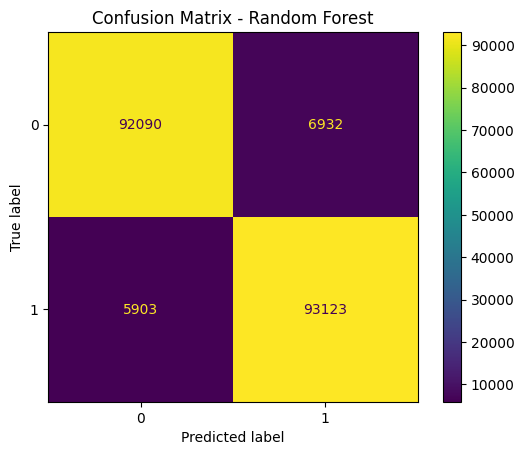

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_clf.predict(X_test)

cm = confusion_matrix(y_clf_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()